In [1]:
 #=============================================================================
# DATASET PREPROCESSING - SKINTIFIC SHOPEE REVIEWS
# Cushion (Makeup) vs Moisturizer (Skincare)
# Objective: Sentiment & Aspect Analysis for Product Strategy Comparison
# =============================================================================

# STEP 0: INSTALL REQUIRED LIBRARIES (run this first if not installed)
# !pip install emoji langdetect nltk pandas
!pip install emoji langdetect nltk pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 17.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 11.6 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=b844352dfb117e55ca83dd2240fc214f2991857b4f7a3e28c8b3df70c2af39c7
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [4]:
#=============================================================================
# DATASET PREPROCESSING - SKINTIFIC SHOPEE REVIEWS
# Cushion (Makeup) vs Moisturizer (Skincare)
# Objective: Sentiment & Aspect Analysis for Product Strategy Comparison
# =============================================================================

# STEP 0: INSTALL REQUIRED LIBRARIES (run this first if not installed)
# !pip install emoji langdetect nltk pandas
import pandas as pd
import re
import emoji
from langdetect import detect, LangDetectException
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

In [5]:
# =============================================================================
# STEP 1: LOAD BOTH DATASETS
# =============================================================================

print("=" * 60)
print("STEP 1: LOAD BOTH DATASETS")
print("=" * 60)

cushion = pd.read_csv('shopee_proportional_cushion.csv', encoding='utf-8')
cushion['product'] = 'cushion'

moisturizer = pd.read_csv('shopee_proportional_moisturizer.csv', encoding='utf-8')
moisturizer['product'] = 'moisturizer'

# Add a label column to identify which product each review belongs to
cushion['product'] = 'cushion'
moisturizer['product'] = 'moisturizer'

# Combine into one dataframe
df = pd.concat([cushion, moisturizer], ignore_index=True)

print(f"Cushion rows       : {len(cushion)}")
print(f"Moisturizer rows   : {len(moisturizer)}")
print(f"Combined total     : {len(df)}")
print(f"Columns            : {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nStar Rating Distribution:")
print(df.groupby(['product', 'stars']).size().unstack(fill_value=0))

STEP 1: LOAD BOTH DATASETS
Cushion rows       : 3579
Moisturizer rows   : 3714
Combined total     : 7293
Columns            : ['author', 'stars', 'comment', 'product']

Missing values:
author     0
stars      0
comment    0
product    0
dtype: int64

Star Rating Distribution:
stars          1   2    3    4     5
product                             
cushion      102  55  172  200  3050
moisturizer  116  58  200  290  3050


In [6]:
# =============================================================================
# STEP 2: SENTIMENT LABELING (from star ratings)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 2: SENTIMENT LABELING")
print("=" * 60)

def assign_sentiment(stars):
    if stars >= 4:
        return 'positive'
    elif stars == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['stars'].apply(assign_sentiment)

print("Sentiment Distribution by Product:")
print(df.groupby(['product', 'sentiment']).size().unstack(fill_value=0))


STEP 2: SENTIMENT LABELING
Sentiment Distribution by Product:
sentiment    negative  neutral  positive
product                                 
cushion           157      172      3250
moisturizer       174      200      3340


In [7]:
# =============================================================================
# STEP 3: STRUCTURED TAG EXTRACTION
# =============================================================================

print("\n" + "=" * 60)
print("STEP 3: STRUCTURED TAG EXTRACTION")
print("=" * 60)

def extract_tags(text):
    """
    Extract key:value structured tags from review comments.
    e.g. "Coverage:good Texture:smooth  Great product!"
    Returns a dictionary: {'Coverage': 'good', 'Texture': 'smooth'}
    """
    tags = re.findall(r'([A-Za-z ]+):([^A-Z\n]+)', str(text))
    return {k.strip(): v.strip() for k, v in tags}

def remove_tags(text):
    """
    Remove structured tag portion, keeping only the free-text review.
    """
    cleaned = re.sub(r'[A-Za-z ]+:[^\n]*?(?=\s{2,})', '', str(text))
    cleaned = re.sub(r'^[A-Za-z ]+:[^\s]*\s*', '', cleaned).strip()
    return cleaned

df['tags'] = df['comment'].apply(extract_tags)
df['free_text'] = df['comment'].apply(remove_tags)

# Show top tags per product
print("Top Tags - Cushion:")
cushion_tags = [k for tags in df[df['product']=='cushion']['tags'] for k in tags.keys()]
print(pd.Series(cushion_tags).value_counts().head(5).to_string())

print("\nTop Tags - Moisturizer:")
moist_tags = [k for tags in df[df['product']=='moisturizer']['tags'] for k in tags.keys()]
print(pd.Series(moist_tags).value_counts().head(5).to_string())


STEP 3: STRUCTURED TAG EXTRACTION
Top Tags - Cushion:
Packaging           741
Beauty Effect       713
Usage Experience    668
Beauty Profile      647
Benefits            627

Top Tags - Moisturizer:
Skin Suitability    1184
Absorption          1119
Effectiveness         56
Skin suitability      44
Texture               43


In [8]:
# =============================================================================
# STEP 4: LANGUAGE DETECTION & FILTER (Keep English Only)
# =============================================================================

print("\n" + "=" * 60)
print("STEP 4: LANGUAGE DETECTION & FILTER (English Only)")
print("=" * 60)

def is_english(text):
    """
    Returns True if text is detected as English.
    """
    try:
        if not text or len(text.strip()) < 10:
            return False
        return detect(text) == 'en'
    except LangDetectException:
        return False

df['is_english'] = df['free_text'].apply(is_english)

before = len(df)
df_eng = df[df['is_english']].copy().reset_index(drop=True)
after = len(df_eng)

print(f"Before filtering : {before} rows")
print(f"After filtering  : {after} rows (English only)")
print(f"Removed          : {before - after} rows (Malay / mixed language)")
print(f"\nEnglish rows by product:")
print(df_eng['product'].value_counts())


STEP 4: LANGUAGE DETECTION & FILTER (English Only)
Before filtering : 7293 rows
After filtering  : 3562 rows (English only)
Removed          : 3731 rows (Malay / mixed language)

English rows by product:
product
moisturizer    1802
cushion        1760
Name: count, dtype: int64


In [9]:
# =============================================================================
# STEP 5: TEXT CLEANING
# =============================================================================

print("\n" + "=" * 60)
print("STEP 5: TEXT CLEANING")
print("=" * 60)

SELLER_BOILERPLATE = [
    r'fast delivery', r'well packed', r'thank you seller', r'tq seller',
    r'good packaging', r'quick delivery', r'great seller', r'good service',
    r'your parcel has been', r'cross[- ]?border transportation',
    r'out from warehouse', r'please wait patiently',
    r'arrived (in )?(good|great|proper|perfect) condition',
    r'packaging (is )?(secure|nice|neat|good|great)',
    r'well received', r'safely received', r'item received',
]

def clean_text(text):
    text = str(text)

    # 1. Encode to utf-8 and decode to fix any encoding issues
    text = text.encode('utf-8', errors='ignore').decode('utf-8')

    # 2. Remove emojis
    text = emoji.replace_emoji(text, replace=' ')

    # 3. Remove unicode artifacts (ellipsis, curly quotes, etc.)
    text = text.encode('ascii', errors='ignore').decode('ascii')

    # 4. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # 5. Remove seller boilerplate
    for pattern in SELLER_BOILERPLATE:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)

    # 6. Remove special characters, keep letters and spaces only
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 7. Lowercase
    text = text.lower()

    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_eng['clean_text'] = df_eng['free_text'].apply(clean_text)

# Remove rows where cleaning left text too short to be meaningful
df_eng = df_eng[df_eng['clean_text'].str.len() > 10].reset_index(drop=True)

print(f"Rows after cleaning: {len(df_eng)}")
print(f"\nExample - Before : {df_eng['free_text'].iloc[0]}")
print(f"Example - After  : {df_eng['clean_text'].iloc[0]}")


STEP 5: TEXT CLEANING
Rows after cleaning: 3549

Example - Before : Wowwww!!!!! Amazing… i so like this foundational very good and easy to use  I love this so much 😙😙😘
Example - After  : wo amazing i so like this foundational very good and easy to use i love this so much


In [10]:
# =============================================================================
# STEP 6: TOKENIZATION
# =============================================================================

print("\n" + "=" * 60)
print("STEP 6: TOKENIZATION")
print("=" * 60)

def tokenize(text):
    return word_tokenize(text)

df_eng['tokens'] = df_eng['clean_text'].apply(tokenize)

print(f"Example tokens: {df_eng['tokens'].iloc[0]}")


STEP 6: TOKENIZATION
Example tokens: ['wo', 'amazing', 'i', 'so', 'like', 'this', 'foundational', 'very', 'good', 'and', 'easy', 'to', 'use', 'i', 'love', 'this', 'so', 'much']


In [11]:
# =============================================================================
# STEP 7: STOP WORD REMOVAL
# =============================================================================

print("\n" + "=" * 60)
print("STEP 7: STOP WORD REMOVAL")
print("=" * 60)

stop_words = set(stopwords.words('english'))

custom_stops = {
    'seller', 'delivery', 'packaging', 'parcel', 'purchase', 'bought',
    'buy', 'order', 'product', 'item', 'price', 'shop', 'shopee',
    'skintific', 'thank', 'tq', 'received', 'get', 'got', 'use',
    'used', 'using', 'would', 'also', 'really', 'very', 'much',
    'still', 'even', 'one', 'two', 'first', 'second', 'time'
}
stop_words.update(custom_stops)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]

df_eng['tokens_no_stop'] = df_eng['tokens'].apply(remove_stopwords)

print(f"Before: {df_eng['tokens'].iloc[0]}")
print(f"After : {df_eng['tokens_no_stop'].iloc[0]}")


STEP 7: STOP WORD REMOVAL
Before: ['wo', 'amazing', 'i', 'so', 'like', 'this', 'foundational', 'very', 'good', 'and', 'easy', 'to', 'use', 'i', 'love', 'this', 'so', 'much']
After : ['amazing', 'like', 'foundational', 'good', 'easy', 'love']


In [12]:
# =============================================================================
# STEP 8: LEMMATIZATION
# =============================================================================

print("\n" + "=" * 60)
print("STEP 8: LEMMATIZATION")
print("=" * 60)

lemmatizer = WordNetLemmatizer()

def lemmatize(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

df_eng['tokens_lemma'] = df_eng['tokens_no_stop'].apply(lemmatize)
df_eng['processed_text'] = df_eng['tokens_lemma'].apply(lambda x: ' '.join(x))

print(f"Before: {df_eng['tokens_no_stop'].iloc[0]}")
print(f"After : {df_eng['tokens_lemma'].iloc[0]}")


STEP 8: LEMMATIZATION
Before: ['amazing', 'like', 'foundational', 'good', 'easy', 'love']
After : ['amazing', 'like', 'foundational', 'good', 'easy', 'love']


In [13]:
# =============================================================================
# STEP 9: CLASS IMBALANCE CHECK
# =============================================================================

print("\n" + "=" * 60)
print("STEP 9: CLASS IMBALANCE CHECK")
print("=" * 60)

print("Sentiment Distribution by Product (final):")
summary = df_eng.groupby(['product', 'sentiment']).size().unstack(fill_value=0)
print(summary)

total_c = df_eng[df_eng['product'] == 'cushion'].shape[0]
total_m = df_eng[df_eng['product'] == 'moisturizer'].shape[0]
print(f"\nCushion    - Positive: {round(df_eng[(df_eng['product']=='cushion') & (df_eng['sentiment']=='positive')].shape[0]/total_c*100,1)}%")
print(f"Moisturizer- Positive: {round(df_eng[(df_eng['product']=='moisturizer') & (df_eng['sentiment']=='positive')].shape[0]/total_m*100,1)}%")
print("\n⚠ Note: Both datasets are imbalanced (positive-dominant).")
print("  Apply class weights or SMOTE when building classifiers.")


STEP 9: CLASS IMBALANCE CHECK
Sentiment Distribution by Product (final):
sentiment    negative  neutral  positive
product                                 
cushion            82       86      1586
moisturizer        79       79      1637

Cushion    - Positive: 90.4%
Moisturizer- Positive: 91.2%

⚠ Note: Both datasets are imbalanced (positive-dominant).
  Apply class weights or SMOTE when building classifiers.


In [14]:
# =============================================================================
# STEP 10: FINAL SUMMARY & EXPORT
# =============================================================================

print("\n" + "=" * 60)
print("STEP 10: FINAL SUMMARY & EXPORT")
print("=" * 60)

df_final = df_eng[[
    'product',
    'author',
    'stars',
    'sentiment',
    'tags',
    'free_text',
    'clean_text',
    'processed_text',
    'tokens_lemma'
]].copy()

print(f"Final Combined Dataset Shape: {df_final.shape}")
print(f"\nRows per product:")
print(df_final['product'].value_counts())
print(f"\nSample Output:")
print(df_final[['product', 'stars', 'sentiment', 'processed_text']].head(5).to_string())

# Export combined dataset
df_final.to_csv(r"C:\Users\User\Downloads\skintific_preprocessed.csv", index=False)
print(f"\n✅ Saved: skintific_preprocessed.csv")

# Also export separately if needed
df_final[df_final['product'] == 'cushion'].to_csv(r"C:\Users\User\Downloads\cushion_preprocessed.csv", index=False)
df_final[df_final['product'] == 'moisturizer'].to_csv(r"C:\Users\User\Downloads\moisturizer_preprocessed.csv", index=False)
print(f"✅ Saved: cushion_preprocessed.csv")
print(f"✅ Saved: moisturizer_preprocessed.csv")


STEP 10: FINAL SUMMARY & EXPORT
Final Combined Dataset Shape: (3549, 9)

Rows per product:
product
moisturizer    1795
cushion        1754
Name: count, dtype: int64

Sample Output:
   product  stars sentiment                                                                                                                                                                                                 processed_text
0  cushion      5  positive                                                                                                                                                                       amazing like foundational good easy love
1  cushion      5  positive                                                                                                                                                                                                  function well
2  cushion      5  positive                                                                                      

In [15]:
!pip install -q transformers==4.44.2 datasets==2.21.0 accelerate==0.34.2 evaluate==0.4.3 h5py scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 119.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [16]:
import os
import json
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


In [17]:
from google.colab import files
# Uncomment and run if the file is not already in your Colab working directory:
# uploaded = files.upload()   # select skintific_preprocessed.csv from your computer

DATA_PATH = "skintific_preprocessed.csv"

In [18]:
print("=" * 60)
print("STEP 1: LOAD PREPROCESSED DATASET")
print("=" * 60)

df = pd.read_csv(DATA_PATH)

# Drop rows with empty/NaN clean_text (a handful of rows became empty after cleaning)
df = df.dropna(subset=["clean_text"]).copy()
df = df[df["clean_text"].str.strip().str.len() > 0].reset_index(drop=True)

print(f"Total rows loaded : {len(df)}")
print(f"Columns           : {df.columns.tolist()}")
print(f"\\nSentiment distribution:")
print(df["sentiment"].value_counts())
print(f"\\nSentiment distribution (%):")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))


STEP 1: LOAD PREPROCESSED DATASET
Total rows loaded : 3558
Columns           : ['product', 'author', 'stars', 'sentiment', 'tags', 'free_text', 'clean_text', 'processed_text', 'tokens_lemma']
\nSentiment distribution:
sentiment
positive    3225
neutral      168
negative     165
Name: count, dtype: int64
\nSentiment distribution (%):
sentiment
positive    90.64
neutral      4.72
negative     4.64
Name: proportion, dtype: float64


In [19]:
print("\\n" + "=" * 60)
print("STEP 2: LABEL ENCODING")
print("=" * 60)

label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

df["label"] = df["sentiment"].map(label2id)

print(f"Label mapping: {label2id}")
print(df[["sentiment", "label"]].drop_duplicates().sort_values("label").to_string(index=False))


\n============================================================
STEP 2: LABEL ENCODING
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
sentiment  label
 negative      0
  neutral      1
 positive      2


In [20]:
print("\\n" + "=" * 60)
print("STEP 3: TRAIN / VALIDATION / TEST SPLIT (stratified)")
print("=" * 60)

texts = df["clean_text"].tolist()
labels = df["label"].tolist()

# First split off the test set (15%)
train_val_texts, test_texts, train_val_labels, test_labels = train_test_split(
    texts, labels, test_size=0.15, random_state=SEED, stratify=labels
)

# Then split train_val into train (70% of total) and val (15% of total)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_val_texts, train_val_labels, test_size=0.1765,  # 0.15 / 0.85 ≈ 0.1765
    random_state=SEED, stratify=train_val_labels
)

print(f"Train rows : {len(train_texts)}")
print(f"Val rows   : {len(val_texts)}")
print(f"Test rows  : {len(test_texts)}")

for name, split_labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    counts = pd.Series(split_labels).map(id2label).value_counts()
    print(f"\\n{name} distribution:\\n{counts}")


\n============================================================
STEP 3: TRAIN / VALIDATION / TEST SPLIT (stratified)
Train rows : 2490
Val rows   : 534
Test rows  : 534
\nTrain distribution:\npositive    2257
neutral      118
negative     115
Name: count, dtype: int64
\nVal distribution:\npositive    484
neutral      25
negative     25
Name: count, dtype: int64
\nTest distribution:\npositive    484
negative     25
neutral      25
Name: count, dtype: int64


In [21]:
print("\\n" + "=" * 60)
print("STEP 4: TOKENIZATION WITH DistilBertTokenizerFast")
print("=" * 60)

MODEL_NAME = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Check review length distribution (in subword tokens) to pick a sensible MAX_LEN
token_lengths = [len(tokenizer.encode(t)) for t in texts]
print(f"Token length — mean: {np.mean(token_lengths):.1f}, "
      f"95th pct: {np.percentile(token_lengths, 95):.0f}, "
      f"max: {np.max(token_lengths)}")

MAX_LEN = 96  # covers the vast majority of reviews; longer ones are truncated

def encode_texts(text_list):
    return tokenizer(
        text_list,
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="np",
    )

train_enc = encode_texts(train_texts)
val_enc   = encode_texts(val_texts)
test_enc  = encode_texts(test_texts)

print(f"\\nExample raw text   : {train_texts[0]}")
print(f"Example tokens      : {tokenizer.convert_ids_to_tokens(train_enc['input_ids'][0])[:20]} ...")
print(f"Example input_ids   : {train_enc['input_ids'][0][:20]} ...")
print(f"Example attn_mask   : {train_enc['attention_mask'][0][:20]} ...")
print(f"\\nShape of train input_ids: {train_enc['input_ids'].shape}")


\n============================================================
STEP 4: TOKENIZATION WITH DistilBertTokenizerFast


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Token length — mean: 20.7, 95th pct: 49, max: 385
\nExample raw text   : ordered on and received on haven t yet to try cleansing and serum but the moisturiser is suitable for me
Example tokens      : ['[CLS]', 'ordered', 'on', 'and', 'received', 'on', 'haven', 't', 'yet', 'to', 'try', 'cleansing', 'and', 'serum', 'but', 'the', 'moist', '##uri', '##ser', 'is'] ...
Example input_ids   : [  101  3641  2006  1998  2363  2006  4033  1056  2664  2000  3046 26799
  1998 20194  2021  1996 11052  9496  8043  2003] ...
Example attn_mask   : [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1] ...
\nShape of train input_ids: (2490, 96)


In [22]:
print("\\n" + "=" * 60)
print("SAVING TOKENIZED REPRESENTATION TO HDF5")
print("=" * 60)

H5_PATH = "skintific_distilbert_encoded.h5"

with h5py.File(H5_PATH, "w") as hf:
    for split_name, enc, lbls in [
        ("train", train_enc, train_labels),
        ("val", val_enc, val_labels),
        ("test", test_enc, test_labels),
    ]:
        grp = hf.create_group(split_name)
        grp.create_dataset("input_ids", data=enc["input_ids"])
        grp.create_dataset("attention_mask", data=enc["attention_mask"])
        grp.create_dataset("labels", data=np.array(lbls))

    hf.attrs["model_name"] = MODEL_NAME
    hf.attrs["max_len"] = MAX_LEN
    hf.attrs["label2id"] = json.dumps(label2id)

print(f"✅ Saved knowledge representation to: {H5_PATH}")

# Quick sanity check: reload and confirm shapes match
with h5py.File(H5_PATH, "r") as hf:
    print(f"\\nVerification — train/input_ids shape: {hf['train']['input_ids'].shape}")
    print(f"Verification — val/input_ids shape  : {hf['val']['input_ids'].shape}")
    print(f"Verification — test/input_ids shape : {hf['test']['input_ids'].shape}")
    print(f"Stored model_name: {hf.attrs['model_name']}, max_len: {hf.attrs['max_len']}")


\n============================================================
SAVING TOKENIZED REPRESENTATION TO HDF5
✅ Saved knowledge representation to: skintific_distilbert_encoded.h5
\nVerification — train/input_ids shape: (2490, 96)
Verification — val/input_ids shape  : (534, 96)
Verification — test/input_ids shape : (534, 96)
Stored model_name: distilbert-base-uncased, max_len: 96


In [23]:
print("\\n" + "=" * 60)
print("STEP 5: BUILDING PYTORCH DATASETS")
print("=" * 60)

class SentimentDataset(torch.utils.data.Dataset):
    """Wraps tokenized input_ids/attention_mask + labels for the HF Trainer."""

    def __init__(self, encodings, labels):
        self.input_ids = torch.tensor(encodings["input_ids"], dtype=torch.long)
        self.attention_mask = torch.tensor(encodings["attention_mask"], dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }

train_dataset = SentimentDataset(train_enc, train_labels)
val_dataset   = SentimentDataset(val_enc, val_labels)
test_dataset  = SentimentDataset(test_enc, test_labels)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size  : {len(val_dataset)}")
print(f"Test dataset size : {len(test_dataset)}")
print(f"\\nExample item keys: {list(train_dataset[0].keys())}")


\n============================================================
STEP 5: BUILDING PYTORCH DATASETS
Train dataset size: 2490
Val dataset size  : 534
Test dataset size : 534
\nExample item keys: ['input_ids', 'attention_mask', 'labels']


In [24]:
print("\\n" + "=" * 60)
print("STEP 6: COMPUTE CLASS WEIGHTS")
print("=" * 60)

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=np.array(train_labels),
)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float).to(device)

print("Class weights (negative, neutral, positive):")
for i, w in enumerate(class_weights_arr):
    print(f"  {id2label[i]:10s} -> weight {w:.3f}")


\n============================================================
STEP 6: COMPUTE CLASS WEIGHTS
Class weights (negative, neutral, positive):
  negative   -> weight 7.217
  neutral    -> weight 7.034
  positive   -> weight 0.368


In [25]:
print("\\n" + "=" * 60)
print("STEP 7: LOAD MODEL")
print("=" * 60)

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
).to(device)

print(f"Model loaded: {MODEL_NAME}")
print(f"Number of parameters: {model.num_parameters():,}")


\n============================================================
STEP 7: LOAD MODEL


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: distilbert-base-uncased
Number of parameters: 66,955,779


In [26]:
class WeightedTrainer(Trainer):
    """Trainer with a class-weighted cross-entropy loss to counter class imbalance."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


In [27]:
training_args = TrainingArguments(
    output_dir="./distilbert_sentiment_checkpoints",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=20,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),  # mixed precision speeds up training on GPU
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [28]:
print("\\n" + "=" * 60)
print("STEP 7b: TRAINING")
print("=" * 60)

train_result = trainer.train()
print(train_result)


\n============================================================
STEP 7b: TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.865600,1.047747,0.919476,0.717650,0.464601,0.519741
2,0.551100,1.002981,0.928839,0.671431,0.594490,0.625706
3,0.631100,0.953531,0.915730,0.642990,0.678182,0.657059
4,0.355300,1.045932,0.934457,0.705310,0.672424,0.687316


TrainOutput(global_step=624, training_loss=0.6867188620261657, metrics={'train_runtime': 73.3272, 'train_samples_per_second': 135.83, 'train_steps_per_second': 8.51, 'total_flos': 247387278712320.0, 'train_loss': 0.6867188620261657, 'epoch': 4.0})


In [29]:
print("\\n" + "=" * 60)
print("STEP 8: EVALUATE ON TEST SET")
print("=" * 60)

test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_true = test_results.label_ids

print(f"Test Accuracy   : {accuracy_score(test_true, test_preds):.4f}")
precision, recall, f1, _ = precision_recall_fscore_support(
    test_true, test_preds, average="macro", zero_division=0
)
print(f"Test Macro Precision: {precision:.4f}")
print(f"Test Macro Recall   : {recall:.4f}")
print(f"Test Macro F1       : {f1:.4f}")

print("\\nFull classification report:")
print(classification_report(
    test_true, test_preds,
    target_names=[id2label[i] for i in range(3)],
    zero_division=0,
))

\n============================================================
STEP 8: EVALUATE ON TEST SET


Test Accuracy   : 0.9139
Test Macro Precision: 0.6004
Test Macro Recall   : 0.5890
Test Macro F1       : 0.5944
\nFull classification report:
              precision    recall  f1-score   support

    negative       0.48      0.44      0.46        25
     neutral       0.36      0.36      0.36        25
    positive       0.96      0.97      0.96       484

    accuracy                           0.91       534
   macro avg       0.60      0.59      0.59       534
weighted avg       0.91      0.91      0.91       534



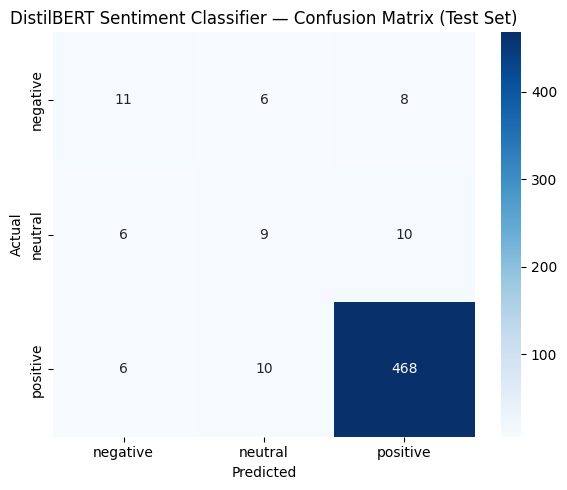

In [30]:
# Confusion matrix
cm = confusion_matrix(test_true, test_preds)
labels_order = [id2label[i] for i in range(3)]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DistilBERT Sentiment Classifier — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix_distilbert.png", dpi=150)
plt.show()


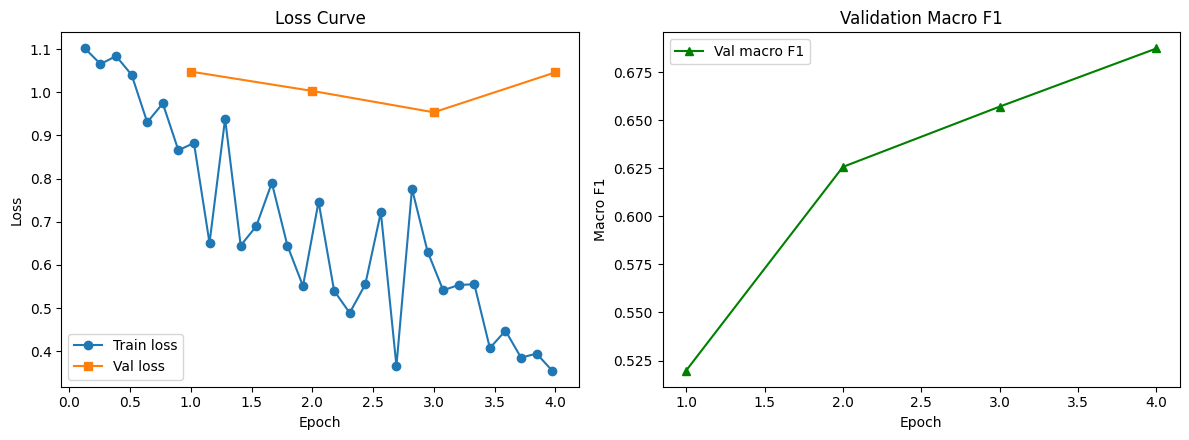

In [31]:
# Training/validation loss & F1 curves across epochs (for the report)
log_history = trainer.state.log_history
train_loss = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
eval_rows = [e for e in log_history if "eval_loss" in e]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

if train_loss:
    epochs_tr, losses_tr = zip(*train_loss)
    axes[0].plot(epochs_tr, losses_tr, marker="o", label="Train loss")
if eval_rows:
    epochs_ev = [e["epoch"] for e in eval_rows]
    losses_ev = [e["eval_loss"] for e in eval_rows]
    axes[0].plot(epochs_ev, losses_ev, marker="s", label="Val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss Curve"); axes[0].legend()

if eval_rows:
    f1_ev = [e["eval_macro_f1"] for e in eval_rows]
    axes[1].plot(epochs_ev, f1_ev, marker="^", color="green", label="Val macro F1")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1"); axes[1].set_title("Validation Macro F1"); axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves_distilbert.png", dpi=150)
plt.show()


In [32]:
print("\\n" + "=" * 60)
print("STEP 9: SAVE FINE-TUNED MODEL & TOKENIZER")
print("=" * 60)

SAVE_DIR = "distilbert_skintific_sentiment_model"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"✅ Model + tokenizer saved to: {SAVE_DIR}")
print("   (Zip this folder and include it under /Source Codes or /Data for submission,")
print("    or load it directly in your deployment app with:")
print("    `model = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)`)")


\n============================================================
STEP 9: SAVE FINE-TUNED MODEL & TOKENIZER
✅ Model + tokenizer saved to: distilbert_skintific_sentiment_model
   (Zip this folder and include it under /Source Codes or /Data for submission,
    or load it directly in your deployment app with:
    `model = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)`)


In [33]:
# Optional: zip the saved model folder for easy download from Colab
import shutil
shutil.make_archive(SAVE_DIR, "zip", SAVE_DIR)
print(f"✅ Zipped model folder: {SAVE_DIR}.zip")

# from google.colab import files
# files.download(f"{SAVE_DIR}.zip")


✅ Zipped model folder: distilbert_skintific_sentiment_model.zip


In [34]:
print("\\n" + "=" * 60)
print("STEP 10: SAMPLE INFERENCE")
print("=" * 60)

def predict_sentiment(text, model=model, tokenizer=tokenizer, max_len=MAX_LEN):
    model.eval()
    enc = tokenizer(text, padding="max_length", truncation=True,
                     max_length=max_len, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred_id = int(np.argmax(probs))
    return id2label[pred_id], {id2label[i]: round(float(p), 4) for i, p in enumerate(probs)}

sample_reviews = [
    "this product is amazing, my skin feels so smooth and hydrated!",
    "it was okay, nothing special, does the basic job",
    "terrible, broke me out badly and smells weird, waste of money",
]

for review in sample_reviews:
    label, probs = predict_sentiment(review)
    print(f"\\nReview   : {review}")
    print(f"Predicted: {label}")
    print(f"Probs    : {probs}")


\n============================================================
STEP 10: SAMPLE INFERENCE
\nReview   : this product is amazing, my skin feels so smooth and hydrated!
Predicted: positive
Probs    : {'negative': 0.006, 'neutral': 0.0141, 'positive': 0.9799}
\nReview   : it was okay, nothing special, does the basic job
Predicted: positive
Probs    : {'negative': 0.0071, 'neutral': 0.0195, 'positive': 0.9734}
\nReview   : terrible, broke me out badly and smells weird, waste of money
Predicted: negative
Probs    : {'negative': 0.77, 'neutral': 0.2065, 'positive': 0.0235}
